# Dose–response regression + NB-GLM

- **Question:** does higher local LTR density predict more V2R copies per cluster?
- **Why GLM not OLS:** response is a count (`n_loci`); often overdispersed → Negative Binomial (Poisson if overdispersion absent).
- **Found:** **no robust positive dose–response** across merge rules, V2R sets, or sensitivity models (BH-adjusted).
- Association without dose–response → co-occurrence / shared niche, not “more LTRs → bigger arrays.”


## Data


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
from scipy.optimize import minimize
from scipy.special import kv
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BT = Path('/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt')
DATA05 = BT / '05'
RES = BT / 'data' / 'results'
FIG = BT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA05 / 'v2r_cluster_density_for_glm.csv')
print(df.shape)
df.head()


(1799, 13)


,chr,start,end,width,n_loci,cluster_id,ltr_bp,all_repeat_bp,ltr_density_bp_per_kb,all_repeat_density_bp_per_kb,gc_mean,merge_bp,aset
0,ch2,131715015,131741076,26062,2,ch2_1,2830,7463,108.587215,286.355614,0.37637,25000.0,v2r_consensus
1,ch2,152003421,152004123,703,1,ch2_2,0,0,0.000000,0.000000,0.45300,25000.0,v2r_consensus
2,ch2,266803937,266807175,3239,1,ch2_3,93,519,28.712566,160.234640,0.41080,25000.0,v2r_consensus
3,ch2,293122983,293123712,730,1,ch2_4,0,0,0.000000,0.000000,0.36300,25000.0,v2r_consensus
4,ch2,293696275,293696994,720,1,ch2_5,0,0,0.000000,0.000000,0.63200,25000.0,v2r_consensus


- `v2r_consensus` = broad (tBLASTn hits)
- `v2r_intact_tblastn` = primary (tBLASTn + intact-pHMM)
- cluster merge distance = 100,000kb (figure below)

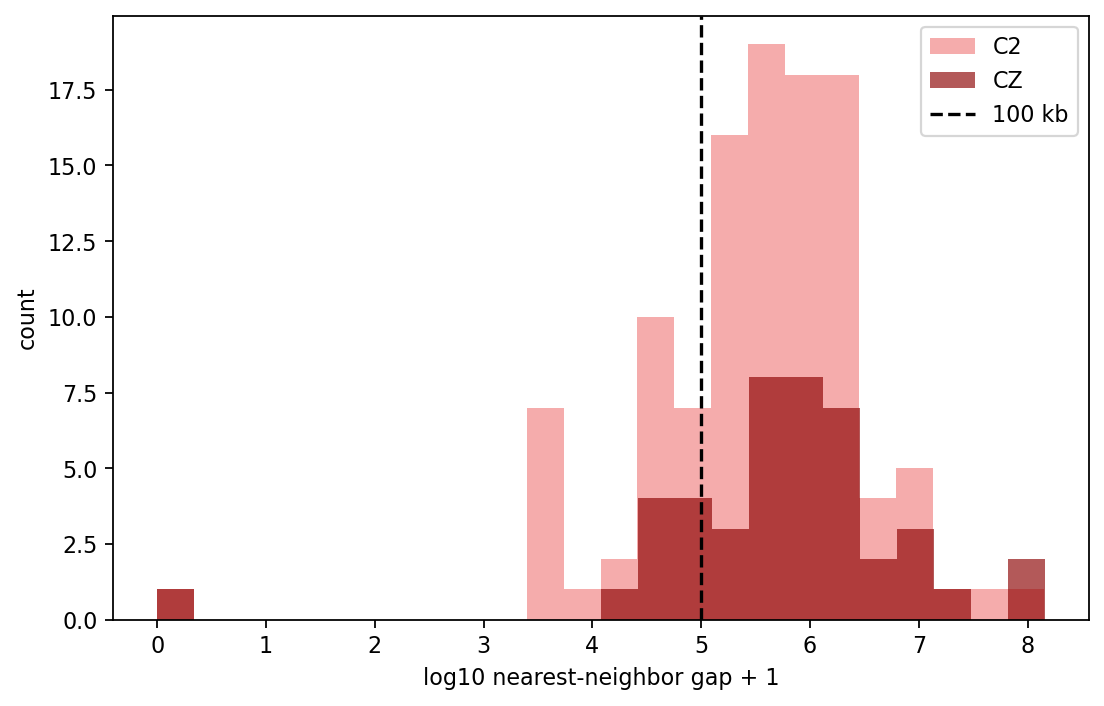

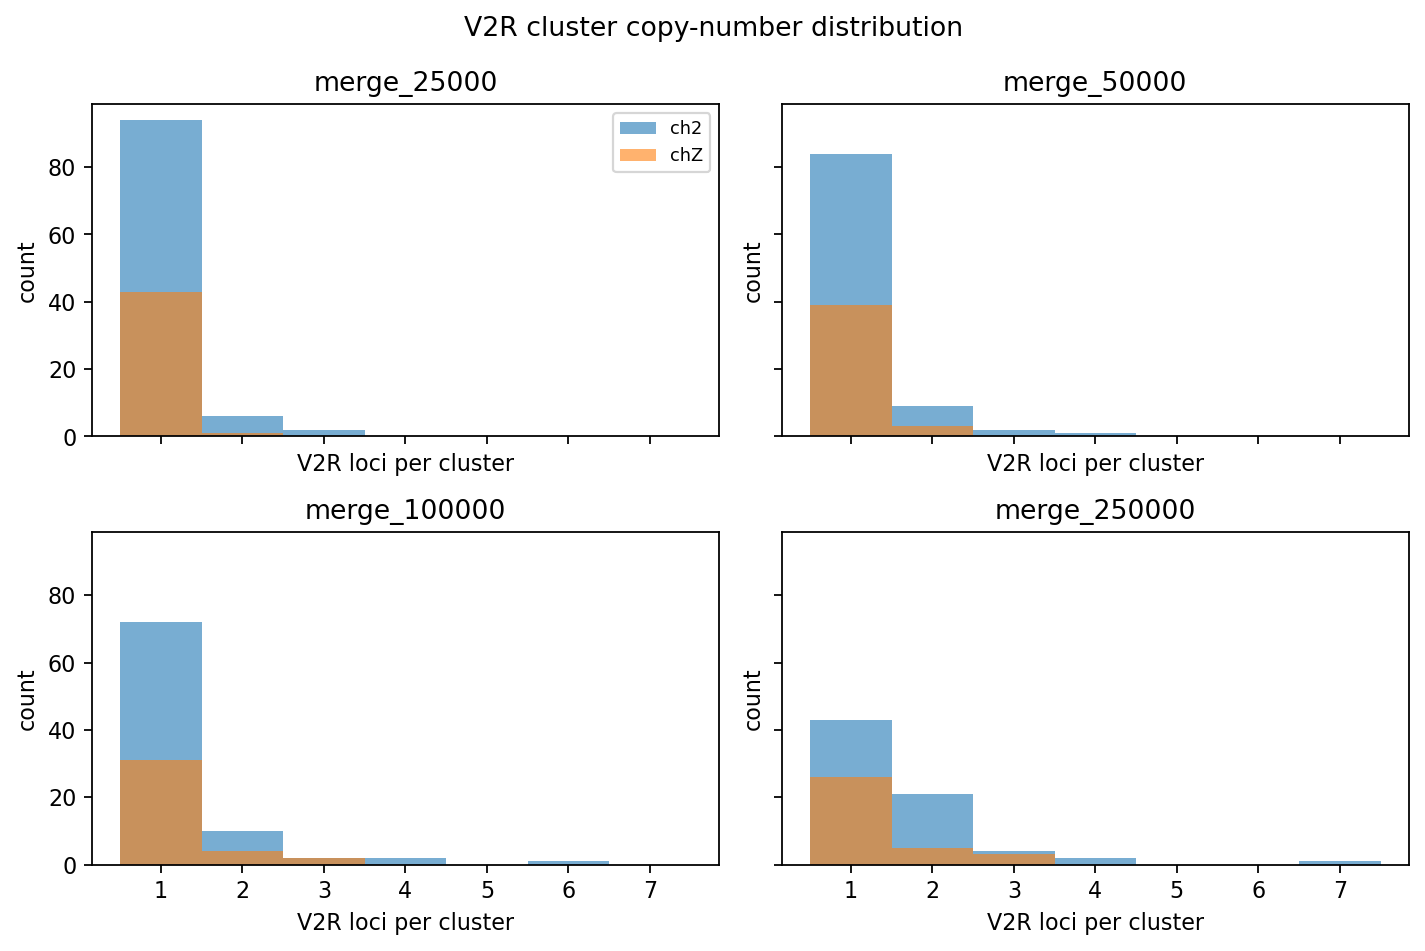

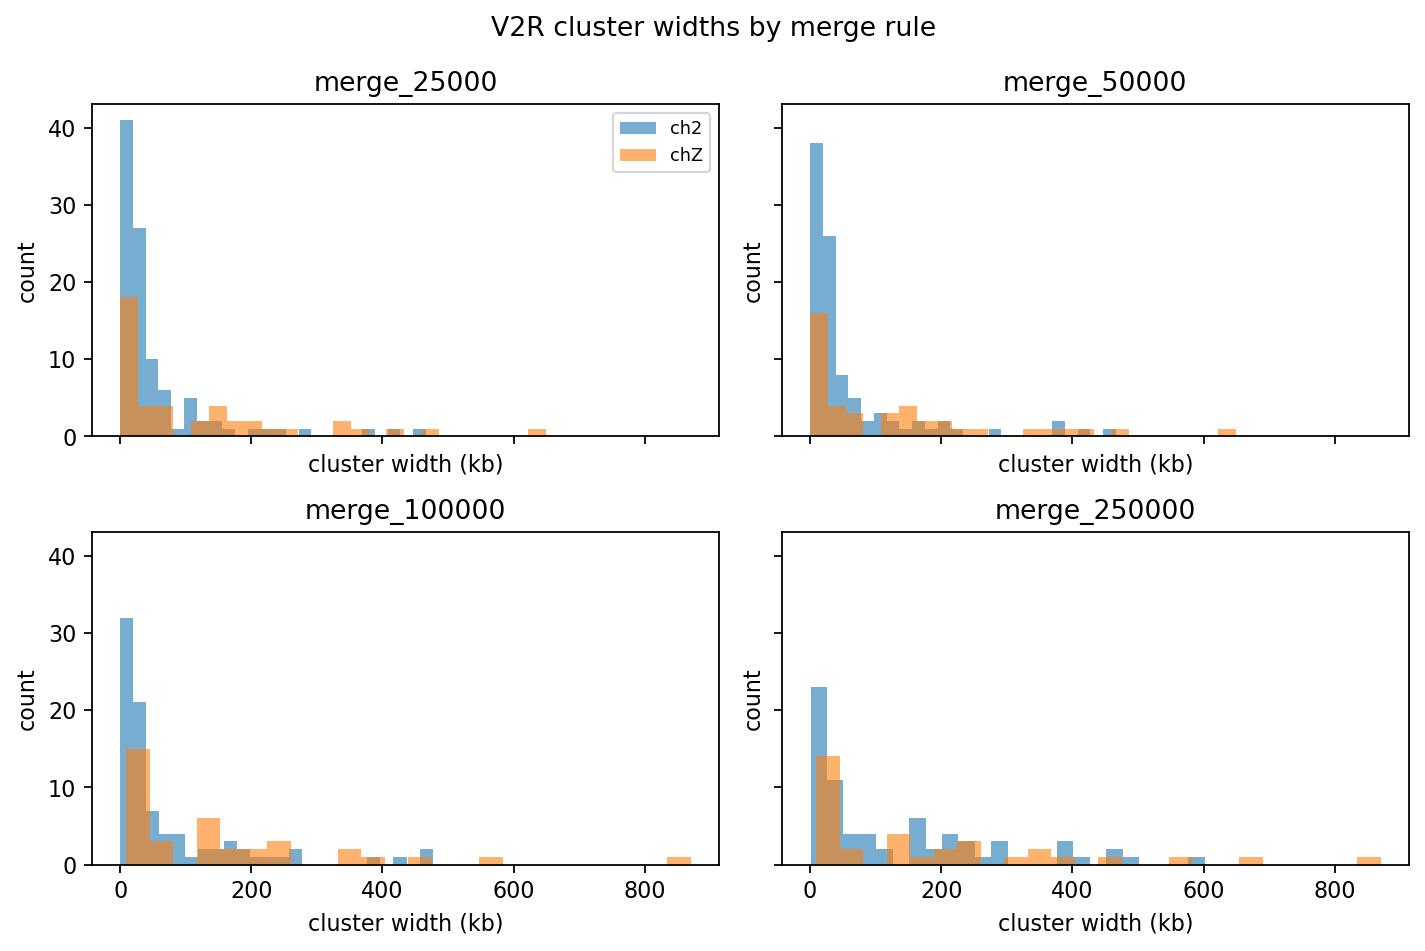

In [32]:
def savefig(name):
    plt.tight_layout()
    out = FIG / name
    plt.savefig(out, bbox_inches='tight', dpi=160)
    plt.close()
    return out

def show(name, title=None, width=900):
    if title:
        display(Markdown(f'**{title}**'))
    display(Image(filename=str(FIG / name), width=width))

nearest = pd.read_csv(DATA05 / 'v2r_intact_tblastn_nearest_gaps.tsv', sep='\t')
clusters = pd.read_csv(DATA05 / 'v2r_cluster_summary.tsv', sep='\t')
rule_order = ['merge_25000', 'merge_50000', 'merge_100000', 'merge_250000']
clusters['merge_rule'] = pd.Categorical(clusters['merge_rule'], categories=rule_order, ordered=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
label_map = {'ch2': 'C2', 'chZ': 'CZ'}
chr_colors = {'C2': '#F08080', 'CZ': '#8B0000'}
for chrom, s in nearest.groupby('chr'):
    lab = label_map.get(chrom, chrom)
    ax.hist(np.log10(s['gap_bp'] + 1), bins=24, alpha=0.65, label=lab,
            color=chr_colors.get(lab, 'crimson'))
ax.axvline(np.log10(1e5 + 1), color='black', linestyle='--', label='100 kb')
ax.set_xlabel('log10 nearest-neighbor gap + 1')
ax.set_ylabel('count')
ax.legend()
savefig('v2r_nearest_gap_distribution.png')

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
for ax, rule in zip(axes.ravel(), rule_order):
    s = clusters[clusters['merge_rule'] == rule]
    for chrom, g in s.groupby('chr', observed=True):
        ax.hist(g['n_loci'], bins=np.arange(1, max(8, int(s['n_loci'].max()) + 2)) - 0.5,
                alpha=0.6, label=chrom)
    ax.set_title(rule)
    ax.set_xlabel('V2R loci per cluster')
    ax.set_ylabel('count')
axes[0, 0].legend(fontsize=8)
fig.suptitle('V2R cluster copy-number distribution')
savefig('v2r_cluster_loci_counts_by_merge_rule.png')

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
for ax, rule in zip(axes.ravel(), rule_order):
    s = clusters[clusters['merge_rule'] == rule]
    for chrom, g in s.groupby('chr', observed=True):
        ax.hist(g['width'] / 1000, bins=24, alpha=0.6, label=chrom)
    ax.set_title(rule)
    ax.set_xlabel('cluster width (kb)')
    ax.set_ylabel('count')
axes[0, 0].legend(fontsize=8)
fig.suptitle('V2R cluster widths by merge rule')
savefig('v2r_cluster_widths_by_merge_rule.png')

show('v2r_nearest_gap_distribution.png')
show('v2r_cluster_loci_counts_by_merge_rule.png')
show('v2r_cluster_widths_by_merge_rule.png')


In [33]:
primary = df[df['merge_bp'] == 100000].copy()
primary['chr'] = primary['chr'].astype('category')

for name, sub in primary.groupby('aset', observed=True):
    print(name)
    print(sub['n_loci'].describe())
    print()


v2r_consensus
count    128.000000
mean      13.132812
std       14.989430
min        1.000000
25%        3.000000
50%        9.000000
75%       17.000000
max       79.000000
Name: n_loci, dtype: float64

v2r_intact_tblastn
count    102.000000
mean       1.539216
std        1.182978
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        9.000000
Name: n_loci, dtype: float64



## Overdispersion check

- Cameron–Trivedi test after a Poisson GLM: positive + significant slope ⇒ overdispersion ⇒ prefer NB.
- PIG (Poisson Inverse Gaussian) is an optional heavier-tailed alternative; kept here only as a short sensitivity check.


In [34]:
def cameron_trivedi_test(y, mu):
    """Cameron & Trivedi (1990) regression-based overdispersion test.
    Positive + significant slope => overdispersion => prefer NB over Poisson.
    """
    y = np.asarray(y, dtype=float)
    mu = np.asarray(mu, dtype=float)
    aux_y = ((y - mu) ** 2 - y) / mu
    aux_fit = sm.OLS(aux_y, mu).fit()
    slope = float(np.asarray(aux_fit.params).ravel()[0])
    pval = float(np.asarray(aux_fit.pvalues).ravel()[0])
    return slope, pval


def fit_pig(y, X, init_beta, maxiter=200):
    """Minimal PIG MLE (optional sensitivity). Returns (success, disp, fitted_mu)."""
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    n_params = X.shape[1]

    def nll(params):
        beta = params[:n_params]
        inv_lam = np.clip(np.exp(params[-1]), 1e-6, 1e4)
        mu = np.clip(np.exp(np.clip(X @ beta, -20, 20)), 1e-6, 1e6)
        sq = np.sqrt(1.0 + 2.0 * mu * inv_lam)
        term1 = 0.5 * (np.log(2.0) - np.log(np.pi) - np.log(inv_lam)) + (1.0 / inv_lam)
        term2 = y * (np.log(mu) - np.log(sq))
        bessel = kv(y - 0.5, np.clip(sq / inv_lam, 1e-5, 700.0))
        bessel = np.where((bessel <= 0) | ~np.isfinite(bessel), 1e-300, bessel)
        ll = term1 + term2 + np.log(bessel)
        return -np.sum(np.where(np.isfinite(ll), ll, -1e10))

    init = np.append(np.asarray(init_beta, dtype=float), np.log(1e-3))
    bounds = [(None, None)] * n_params + [(-12, 10)]
    res = minimize(nll, init, method='L-BFGS-B', bounds=bounds, options={'maxiter': maxiter})
    beta = res.x[:n_params]
    disp = float(np.exp(res.x[-1]))
    mu = np.exp(np.clip(X @ beta, -20, 20))
    ok = bool(res.success or 'stop' in str(res.message).lower())
    return ok, disp, mu, res


## Fit NB / Poisson / PIG GLM

- `n_loci ~ ltr_density_bp_per_kb + gc_mean + C(chr)`
- Overdispersion check (Cameron–Trivedi): choose NB vs Poisson vs PIG


In [39]:
# Primary teaching fit: merge = 100 kb
for aset_val in ['v2r_intact_tblastn', 'v2r_consensus']:
    print(f"\n === Results for aset = {aset_val} === ")
    work = primary.copy()
    if 'aset' in work.columns:
        work = work[work['aset'] == aset_val].copy()
    else:
        print(f"aset column missing in primary: cannot filter {aset_val}")
        continue
    work['chr'] = work['chr'].astype('category')
    assert 'n_loci' in work.columns

    formula = 'n_loci ~ ltr_density_bp_per_kb + gc_mean + C(chr)'

    # Poisson baseline 
    pois = smf.glm(formula, data=work, family=sm.families.Poisson()).fit()
    print('--- Poisson baseline ---')
    print(pois.summary().tables[1])
    pois_ct = cameron_trivedi_test(work['n_loci'], pois.fittedvalues)
    print(f'Cameron-Trivedi (Poisson): slope={pois_ct[0]:.4f}, p={pois_ct[1]:.4g}')

    # NB sensitivity (default alpha=1 if not estimated; still useful as a check)
    nb = smf.glm(formula, data=work, family=sm.families.NegativeBinomial()).fit()
    print('\n--- Negative Binomial ---')
    print(nb.summary().tables[1])
    nb_ct = cameron_trivedi_test(work['n_loci'], nb.fittedvalues)
    print(f'Cameron-Trivedi (NB fitted means): slope={nb_ct[0]:.4f}, p={nb_ct[1]:.4g}')

    # Trimmed PIG sensitivity
    y_mat, X_df = patsy.dmatrices(formula, data=work, return_type='dataframe')
    y = np.asarray(y_mat).ravel().astype(float)
    X = np.asarray(X_df)
    ok, pig_disp, pig_fitted, pig_res = fit_pig(y, X, pois.params.values)
    print('\n--- PIG (trimmed) ---')
    if ok:
        print(f'optimization ok; loglik={-pig_res.fun:.4f}; dispersion(1/lambda)={pig_disp:.6g}')
        if pig_disp < 1e-4:
            print('dispersion ~ 0 → PIG collapses toward Poisson')
        pig_ct = cameron_trivedi_test(y, pig_fitted)
        print(f'Cameron-Trivedi (PIG fitted means): slope={pig_ct[0]:.4f}, p={pig_ct[1]:.4g}')
    else:
        print('PIG optimization did not converge:', pig_res.message)



 === Results for aset = v2r_intact_tblastn === 
--- Poisson baseline ---
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.6333      1.291      1.265      0.206      -0.897       4.163
C(chr)[T.chZ]             0.0262      0.177      0.147      0.883      -0.322       0.374
ltr_density_bp_per_kb     0.0007      0.001      1.255      0.209      -0.000       0.002
gc_mean                  -3.7419      3.175     -1.179      0.239      -9.965       2.481
Cameron-Trivedi (Poisson): slope=-0.0791, p=0.6522

--- Negative Binomial ---
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.7966      2.045      0.879      0.380      -2.211       5.804
C(chr)[T.chZ]             0.0076      

/hpcfs/users/a1864358/miniconda/envs/general/lib/python3.14/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/hpcfs/users/a1864358/miniconda/envs/general/lib/python3.14/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


**`v2r_consensus` → *BROAD* set**

**`v2r_intact_tblastn` → *PRIMARY* set**


##### Model selection (merge = 100 kb)

**Primary (`v2r_intact_tblastn`)**
- Poisson CT: slope ≈ −0.079, p ≈ 0.65 → **no overdispersion** → use **Poisson**
- LTR coefficient ≈ 0.0007, p ≈ 0.21 → **no significant dose–response**
- NB gives the same qualitative answer (LTR ns); default `alpha=1` is unnecessary here
- PIG dispersion ≈ 0 → collapses toward Poisson; ignore its CT slope for model choice

**Broad (`v2r_consensus`)**
- Poisson CT: slope ≈ 1.18, p ≈ 4.5×10⁻⁷ → **strongly overdispersed** → prefer **NB** (estimate α; don’t use default α=1)
- LTR coefficient ≈ −0.0001 to −0.0003, p ≈ 0.45–0.56 → still **no positive dose–response**
- GC is significant under Poisson; weaker / ns under NB -> treat GC as a covariate, not the H2 claim
- PIG again collapses (dispersion ≈ 0); not informative here

**Conclusion**
- Association tests (earlier nulls) ≠ dose–response
- Confirmed primary set: equidispersed Poisson, **no LTR → copy-number dose–response**
- Broad set is noisier/overdispersed, but still **no robust positive LTR dose–response**


## Sensitivity results


In [36]:
sens_path = RES / 'nb_glm_sensitivity_by_merge_bp.csv'
sens = pd.read_csv(sens_path)
print('=== NB-GLM sensitivity by merge_bp ===')
display(sens)

for name in [
    'nosat_glm_v2r_intact_tblastn_results.tsv',
    'flank_ring_glm_v2r_intact_tblastn_results.tsv',
    'flank_profile_glm_v2r_intact_tblastn_results.tsv',
    'joint_body_flank_glm_results.tsv',
    'spatial_robust_glm_results.tsv',
    'reverse_ltr_density_glm_results.tsv',
    'null_d_glm_v2r_intact_tblastn_results.tsv',
]:
    path = RES / name
    if path.exists():
        d = pd.read_csv(path, sep='\t')
        print(f'\n=== {name} ===')
        display(d.head(12))
    else:
        print(f'\n=== {name} === MISSING')


=== NB-GLM sensitivity by merge_bp ===


,merge_bp,aset,n_clusters,alpha_hat,ltr_density_coef,p_value
0,50000,v2r_consensus,358,0.984599,-0.001283,0.000001
1,50000,v2r_intact_tblastn,124,0.000100,0.000021,0.964898
2,100000,v2r_consensus,128,1.184802,-0.000338,0.580996
3,100000,v2r_intact_tblastn,102,0.000100,0.000725,0.209492
4,250000,v2r_consensus,56,2.902848,0.005723,0.000331
5,250000,v2r_intact_tblastn,76,0.106772,0.001568,0.024737



=== nosat_glm_v2r_intact_tblastn_results.tsv ===


,subset,n,n_ch2,n_chZ,formula,model_type,overdisp_slope,overdisp_p,ltr_coef,ltr_rate_ratio,ltr_p,aic,llf,ltr_q_bh
0,pooled,102,73,29,n_loci ~ ltr_density_bp_per_kb + gc_mean + C(c...,Poisson,-0.087725,0.592508,0.000840,1.000841,0.169417,297.793394,-142.896697,0.254126
1,ch2_only,73,73,0,n_loci ~ ltr_density_bp_per_kb + gc_mean + low...,Poisson,-0.225705,0.025537,0.000358,1.000358,0.628540,210.529332,-100.264666,0.628540
2,chZ_only,29,0,29,n_loci ~ ltr_density_bp_per_kb + gc_mean + low...,Poisson,0.195599,0.654107,0.001746,1.001748,0.129524,93.915038,-41.957519,0.254126



=== flank_ring_glm_v2r_intact_tblastn_results.tsv ===


...

,aset,method,coef,rate_ratio,p,note
0,v2r_consensus,1 naive NB-GLM,-0.000338,0.999662,0.580996,"n=128, 18 blocks"
1,v2r_consensus,2 Poisson GEE (10Mb blocks),-0.000078,0.999922,0.892233,"exchangeable, robust SE"
2,v2r_consensus,3 NB-GLM + position spline,-0.001637,0.998365,0.011456,"cr(midpoint, df=5)"
3,v2r_consensus,4 block bootstrap,-0.000305,0.999695,0.896000,"95% CI [-0.00350, 0.00330], 1000 reps"
4,v2r_intact_tblastn,1 naive NB-GLM,0.000725,1.000725,0.209492,"n=102, 16 blocks"
5,v2r_intact_tblastn,2 Poisson GEE (10Mb blocks),0.000701,1.000701,0.216209,"exchangeable, robust SE"
6,v2r_intact_tblastn,3 NB-GLM + position spline,0.000639,1.000639,0.284504,"cr(midpoint, df=5)"
7,v2r_intact_tblastn,4 block bootstrap,0.000677,1.000677,0.186000,"95% CI [-0.00029, 0.00211], 1000 reps"



=== reverse_ltr_density_glm_results.tsv ===


,aset,outcome,model,n,coef_per_locus,rr_per_locus,p
0,v2r_consensus,body,M0 (count+GC+chr),128,-0.000343,0.999657,0.828805
1,v2r_consensus,body,M1 (+assembly/complexity),128,-0.004650,0.995361,0.009420
2,v2r_consensus,0-50kb ring,M0 (count+GC+chr),128,0.002343,1.002346,0.069281
3,v2r_consensus,0-50kb ring,M1 (+assembly/complexity),128,-0.002127,0.997875,0.090698
4,v2r_consensus,0-100kb ring,M0 (count+GC+chr),128,0.002921,1.002925,0.019674
5,v2r_consensus,0-100kb ring,M1 (+assembly/complexity),128,-0.001154,0.998847,0.295237
6,v2r_intact_tblastn,body,M0 (count+GC+chr),102,0.041397,1.042266,0.059165
7,v2r_intact_tblastn,body,M1 (+assembly/complexity),102,0.054498,1.056010,0.008950
8,v2r_intact_tblastn,0-50kb ring,M0 (count+GC+chr),102,-0.020698,0.979515,0.323691
9,v2r_intact_tblastn,0-50kb ring,M1 (+assembly/complexity),102,-0.024834,0.975472,0.165012



=== null_d_glm_v2r_intact_tblastn_results.tsv ===


,subset,n,n_ch2,n_chZ,formula,model_type,overdisp_slope,overdisp_p,ltr_coef,ltr_rate_ratio,ltr_p,aic,llf,ltr_q_bh
0,pooled,102,73,29,n_loci ~ ltr_density_bp_per_kb + gc_mean + C(c...,Poisson,-0.088077,5.910994e-01,0.000825,1.000826,0.054020,301.716032,-142.858016,0.098833
1,ch2_only,73,73,0,n_loci ~ ltr_density_bp_per_kb + gc_mean + low...,Poisson,-0.229875,1.962613e-02,0.000312,1.000312,0.417189,213.861070,-99.930535,0.417189
2,chZ_only,29,0,29,n_loci ~ ltr_density_bp_per_kb + gc_mean + low...,Poisson,0.185579,6.398054e-01,0.001925,1.001927,0.059300,95.646811,-41.823406,0.098833
3,width_low,34,23,11,not_fit,skipped_insufficient_n_or_no_outcome_variation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,width_mid,34,29,5,n_loci ~ ltr_density_bp_per_kb + gc_mean + C(c...,Poisson,-0.733835,4.806105e-20,-0.002360,0.997643,0.000015,88.531645,-37.265823,0.000076
5,width_high,34,21,13,n_loci ~ ltr_density_bp_per_kb + gc_mean + C(c...,Poisson,0.025291,8.968058e-01,-0.001713,0.998288,0.121428,129.558963,-58.779481,0.151786


## 16-specification sensitivity + Benjamini–Hochberg

Flank-ring predictor search (merge × ring width × LTR vs `LTR/unknown` × pooled vs ch2-only = **16** models).
Custom BH-FDR across all 16; report target: **min q = 0.1787**, none survive *q* < 0.05.


In [41]:
def bh_adjust(pvals):
    """Benjamini–Hochberg FDR q-values (step-up, monotone)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    finite = np.isfinite(p)
    vals = p[finite]
    order = np.argsort(vals)
    ranked = vals[order]
    n = len(ranked)
    adj = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        val = ranked[i] * n / (i + 1)
        prev = min(prev, val)
        adj[i] = prev
    tmp = np.empty(n)
    tmp[order] = adj
    out[finite] = tmp
    return out


flank_path = (
    Path('/hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/05/v2r_cluster_flank_ring_density_for_glm.csv')
)
flank = pd.read_csv(flank_path)
flank['chr'] = flank['chr'].astype('category')


def fit_spec(sub, predictor):
    if sub[predictor].std() == 0 or len(sub) < 15:
        return None
    formula = (
        f'n_loci ~ {predictor} + C(chr)'
        if sub['chr'].nunique() > 1
        else f'n_loci ~ {predictor}'
    )
    pois = smf.glm(formula, data=sub, family=sm.families.Poisson()).fit()
    slope, p_ct = cameron_trivedi_test(sub['n_loci'].values, pois.fittedvalues.values)
    alpha_hat = max(slope, 1e-4)
    nb = smf.glm(
        formula, data=sub, family=sm.families.NegativeBinomial(alpha=alpha_hat)
    ).fit()
    return {
        'n': len(sub),
        'alpha': alpha_hat,
        'ct_p': p_ct,
        'coef': float(nb.params[predictor]),
        'rate_ratio': float(np.exp(nb.params[predictor])),
        'p': float(nb.pvalues[predictor]),
    }


rows = []
for merge_bp in [25000, 100000]:
    for ring_bp in [5000, 10000]:
        sub_all = flank[(flank.merge_bp == merge_bp) & (flank.ring_bp == ring_bp)]
        sub_ch2 = sub_all[sub_all.chr == 'ch2']
        for predictor in ['ltr_ring_density_bp_per_kb', 'unk_ring_density_bp_per_kb']:
            for subset, sub in [('pooled', sub_all), ('ch2-only', sub_ch2)]:
                fit = fit_spec(sub, predictor)
                if fit is None:
                    continue
                rows.append({
                    'merge_bp': merge_bp,
                    'ring_bp': ring_bp,
                    'predictor': predictor,
                    'subset': subset,
                    **fit,
                })

spec = pd.DataFrame(rows)
spec['q_bh'] = bh_adjust(spec['p'].to_numpy())
display(spec.sort_values('p'))

print(f"n specifications: {len(spec)}")
print(f"smallest BH-adjusted q-value across all 16 specifications: {spec['q_bh'].min():.4f}")
print(f"any specification survives q < 0.05: {bool((spec['q_bh'] < 0.05).any())}")


,merge_bp,ring_bp,predictor,subset,n,alpha,ct_p,coef,rate_ratio,p,q_bh
10,100000,5000,unk_ring_density_bp_per_kb,pooled,128,1.093929,0.000001,0.002133,1.002135,0.011167,0.178664
11,100000,5000,unk_ring_density_bp_per_kb,ch2-only,87,1.007906,0.000003,0.001873,1.001875,0.037461,0.266580
15,100000,10000,unk_ring_density_bp_per_kb,ch2-only,87,1.000704,0.000008,0.002418,1.002421,0.061993,0.266580
14,100000,10000,unk_ring_density_bp_per_kb,pooled,128,1.155444,0.000011,0.002019,1.002021,0.090231,0.266580
2,25000,5000,unk_ring_density_bp_per_kb,pooled,823,0.121648,0.074027,-0.000386,0.999615,0.096945,0.266580
6,25000,10000,unk_ring_density_bp_per_kb,pooled,823,0.121534,0.075694,-0.000473,0.999527,0.099968,0.266580
5,25000,10000,ltr_ring_density_bp_per_kb,ch2-only,528,0.157531,0.043069,0.000324,1.000324,0.131674,0.271862
4,25000,10000,ltr_ring_density_bp_per_kb,pooled,823,0.121689,0.079735,0.000257,1.000257,0.135931,0.271862
3,25000,5000,unk_ring_density_bp_per_kb,ch2-only,528,0.159213,0.046286,-0.000292,0.999708,0.279015,0.496028
7,25000,10000,unk_ring_density_bp_per_kb,ch2-only,528,0.159248,0.047503,-0.000339,0.999661,0.311660,0.498657


n specifications: 16
smallest BH-adjusted q-value across all 16 specifications: 0.1787
any specification survives q < 0.05: False


## Dose–response scatter (primary merge = 100 kb)

Broad vs primary clusters: V2R copy number vs local LTR density (LOWESS). Matches tech-report Fig. 3 panel.


wrote /hpcfs/users/a1864358/sanders_lab/repeatdensity-atv2rs/final-bt/figures/fig3_nb_glm.png


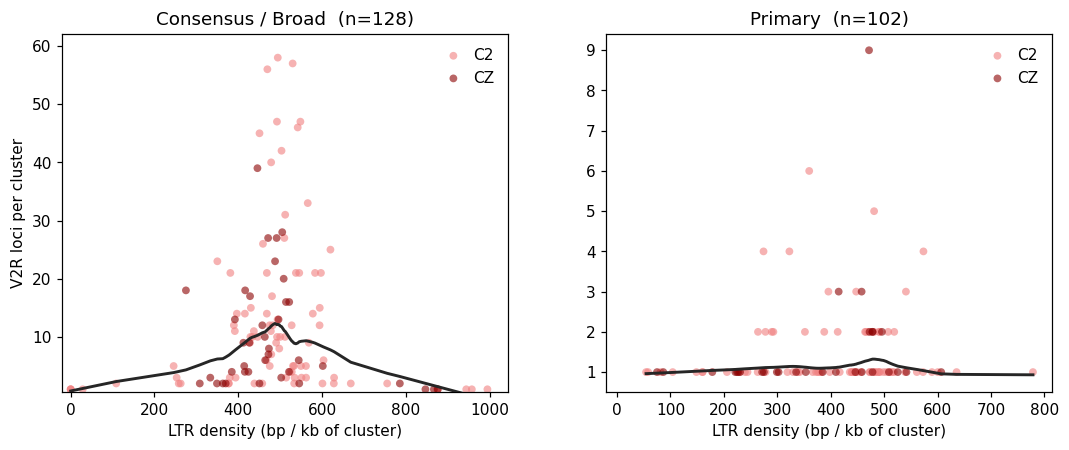

In [42]:
from statsmodels.nonparametric.smoothers_lowess import lowess

clust = df.copy()
primary_plot = clust[clust['merge_bp'] == 100000].copy()
chr_lab = {'ch2': 'C2', 'chZ': 'CZ'}
chr_col = {'ch2': '#F08080', 'chZ': '#8B0000'}
aset_order = ['v2r_consensus', 'v2r_intact_tblastn']
aset_lab = {
    'v2r_consensus': 'Consensus / Broad',
    'v2r_intact_tblastn': 'Primary',
}

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4), sharey=False)
for ax, aset in zip(axes, aset_order):
    sub = primary_plot[primary_plot['aset'] == aset]
    for chrom, g in sub.groupby('chr'):
        ax.scatter(
            g['ltr_density_bp_per_kb'], g['n_loci'],
            s=26, alpha=0.6, color=chr_col[chrom],
            edgecolors='none', label=chr_lab[chrom], zorder=2,
        )
    order = np.argsort(sub['ltr_density_bp_per_kb'].to_numpy())
    x = sub['ltr_density_bp_per_kb'].to_numpy()[order]
    y = sub['n_loci'].to_numpy(float)[order]
    sm = lowess(y, x, frac=0.45, return_sorted=True)
    ax.plot(sm[:, 0], sm[:, 1], color='0.15', lw=1.9, zorder=4)
    ax.set_title(f'{aset_lab[aset]}  (n={len(sub)})', fontsize=12, pad=6)
    ax.set_xlabel('LTR density (bp / kb of cluster)', labelpad=4)
    ax.set_xlim(left=-20)
    ax.set_ylim(bottom=0.5)
    if aset == 'v2r_consensus':
        ax.set_ylabel('V2R loci per cluster', labelpad=4)
        ax.set_ylim(0.5, max(8, np.percentile(sub['n_loci'], 98) * 1.08))
    ax.legend(frameon=False, loc='upper right', fontsize=10, handletextpad=0.3)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.88, wspace=0.22)
out = FIG / 'fig3_nb_glm.png'
fig.savefig(out, bbox_inches='tight', dpi=160)
print('wrote', out)
plt.show()
